# 00a — Data Collection: PDF → Images

**Manual step:** Download PDFs from the sources below and place them in `data/pdfs/`.

This notebook then converts every PDF page to a PNG image in `data/raw/`.
Blank pages and near-empty pages are automatically skipped.

## Download sources

| Source | Type | URL |
|---|---|---|
| Nepal Rastra Bank | Annual reports | https://www.nrb.org.np/category/annual-reports/annual-reports-english/ |
| NRB | Bank supervision reports | https://www.nrb.org.np/category/annual-reports/bank-supervision-report/ |
| NRB | Financial stability reports | https://www.nrb.org.np/category/annual-reports/financial-stability-report/ |
| SEBON | Capital market annual reports | https://www.sebon.gov.np/annual-report |
| Ministry of Finance | Budget speeches | https://mof.gov.np/category/budget-speech/ |
| Nepal Bank Ltd | Annual reports | https://www.nepalbank.com.np/investor-relations/agm-reports/annual-reports |
| Everest Bank | Annual reports | https://everestbankltd.com/financialreports/annual-report/ |
| Nabil Bank | Annual reports | https://www.nabilbank.com/investor-relations |
| NIC Asia | Annual reports | https://www.nicasiabank.com/investors |
| MeroLagani | All NEPSE-listed companies | https://merolagani.com/CompanyReports.aspx?type=ANNUAL |

**Tip:** Aim for 20–30 PDFs across different document types (annual reports, bank statements, budget docs).
Variety in layout, font, and structure makes the orientation classifier more robust.

In [1]:
import sys
sys.path.insert(0, '..')

from pathlib import Path
import fitz  # PyMuPDF
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import random

PDF_DIR = Path('../data/pdfs')
RAW_DIR = Path('../data/raw')
PDF_DIR.mkdir(parents=True, exist_ok=True)
RAW_DIR.mkdir(parents=True, exist_ok=True)

DPI       = 150   # sufficient for orientation classification
MAX_PAGES = 30    # cap per PDF — avoids 200-page reports dominating the dataset

pdfs = sorted(PDF_DIR.glob('*.pdf'))
print(f'PDFs found in data/pdfs/: {len(pdfs)}')
for p in pdfs:
    print(f'  {p.name}  ({p.stat().st_size // 1024} KB)')

PDFs found in data/pdfs/: 9
  Audit Report (1).pdf  (2013 KB)
  Audit Report NFRS Sample 1 (1).pdf  (4829 KB)
  Audit Report NFRS Sample 2 (2).pdf  (1653 KB)
  Chitwan_Management_Meeting_25_27_dec_2014_final.pdf  (919 KB)
  NFRS CLASS D SAMPLE (1).pdf  (1437 KB)
  Provisional Report.pdf  (1726 KB)
  national Microfinance Annual Report FY 2077-78.pdf  (10495 KB)
  pdfoverimage.pdf  (38 KB)
  वार्षिक प्रतिवेदन New 1_naavn9s.pdf  (363 KB)


In [2]:
# ── Blank page detection ──────────────────────────────────────────────────────
# Skip pages that are mostly white (covers, intentional blank pages).
# Threshold: if >97% of pixels are near-white, skip the page.

def is_blank(img_bgr: np.ndarray, white_threshold: int = 250, blank_ratio: float = 0.97) -> bool:
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    white_pixels = np.sum(gray >= white_threshold)
    return white_pixels / gray.size >= blank_ratio

print('Blank page detector ready.')

Blank page detector ready.


In [3]:
# ── PDF → Images ──────────────────────────────────────────────────────────────

records = []
skipped_blank = 0
mat = fitz.Matrix(DPI / 72, DPI / 72)

for pdf_path in tqdm(pdfs, desc='Converting PDFs'):
    doc = fitz.open(str(pdf_path))
    total_pages = len(doc)
    pages_to_extract = min(total_pages, MAX_PAGES)
    extracted = 0

    for i in range(pages_to_extract):
        pix = doc[i].get_pixmap(matrix=mat, colorspace=fitz.csRGB)
        img_array = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.h, pix.w, 3)
        img_bgr = cv2.cvtColor(img_array, cv2.COLOR_RGB2BGR)

        if is_blank(img_bgr):
            skipped_blank += 1
            continue

        img_name = f'{pdf_path.stem}_page{i+1:04d}.png'
        img_out = RAW_DIR / img_name
        cv2.imwrite(str(img_out), img_bgr)

        records.append({
            'image_path': str(img_out.resolve()),
            'source_pdf': pdf_path.name,
            'page': i + 1,
        })
        extracted += 1

    doc.close()
    print(f'  {pdf_path.name}: {extracted} pages extracted  (total pages: {total_pages})')

manifest = pd.DataFrame(records)
manifest.to_csv(Path('../data/raw_manifest.csv'), index=False)

print(f'\nTotal images extracted : {len(manifest)}')
print(f'Blank pages skipped    : {skipped_blank}')
print(f'Manifest saved         → data/raw_manifest.csv')

Converting PDFs:   0%|          | 0/9 [00:00<?, ?it/s]

Converting PDFs:  11%|█         | 1/9 [00:00<00:04,  1.96it/s]

  Audit Report (1).pdf: 7 pages extracted  (total pages: 8)


Converting PDFs:  22%|██▏       | 2/9 [00:01<00:06,  1.16it/s]

  Audit Report NFRS Sample 1 (1).pdf: 30 pages extracted  (total pages: 59)


...

Converting PDFs:  78%|███████▊  | 7/9 [00:04<00:01,  1.36it/s]

  national Microfinance Annual Report FY 2077-78.pdf: 30 pages extracted  (total pages: 62)
  pdfoverimage.pdf: 1 pages extracted  (total pages: 1)


Converting PDFs: 100%|██████████| 9/9 [00:05<00:00,  2.05it/s]

Converting PDFs: 100%|██████████| 9/9 [00:05<00:00,  1.72it/s]

  वार्षिक प्रतिवेदन New 1_naavn9s.pdf: 27 pages extracted  (total pages: 36)

Total images extracted : 138
Blank pages skipped    : 7
Manifest saved         → data/raw_manifest.csv


In [4]:
# ── Per-PDF breakdown ─────────────────────────────────────────────────────────
print(manifest.groupby('source_pdf')['page'].count().rename('pages_extracted').to_string())

source_pdf
Audit Report (1).pdf                                    7
Audit Report NFRS Sample 1 (1).pdf                     30
Audit Report NFRS Sample 2 (2).pdf                     13
Chitwan_Management_Meeting_25_27_dec_2014_final.pdf    17
NFRS CLASS D SAMPLE (1).pdf                             6
Provisional Report.pdf                                  7
national Microfinance Annual Report FY 2077-78.pdf     30
pdfoverimage.pdf                                        1
वार्षिक प्रतिवेदन New 1_naavn9s.pdf                    27


/var/folders/ks/2hntfc9531d20w4m1bjd8w400000gn/T/ipykernel_60714/2840755759.py:14: UserWarning: Glyph 2357 (\N{DEVANAGARI LETTER VA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ks/2hntfc9531d20w4m1bjd8w400000gn/T/ipykernel_60714/2840755759.py:14: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/var/folders/ks/2hntfc9531d20w4m1bjd8w400000gn/T/ipykernel_60714/2840755759.py:14: UserWarning: Glyph 2366 (\N{DEVANAGARI VOWEL SIGN AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ks/2hntfc9531d20w4m1bjd8w400000gn/T/ipykernel_60714/2840755759.py:14: UserWarning: Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ks/2hntfc9531d20w4m1bjd8w400000gn/T/ipykernel_60714/2840755759.py:14: UserWarning: Glyph 2381 (\N{DEVANAGARI SIGN VIRAMA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ks/2hntfc9531d20w4m1bjd8w400000gn/T/ipykernel_607

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 2357 (\N{DEVANAGARI LETTER VA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Matplotlib currently does not support Devanagari natively.
  fig.canvas.print_figure(bytes_io, **kw)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 2366 (\N{DEVANAGARI VOWEL SIGN AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Library/Frameworks/Python.framework/Versions/3.12/li

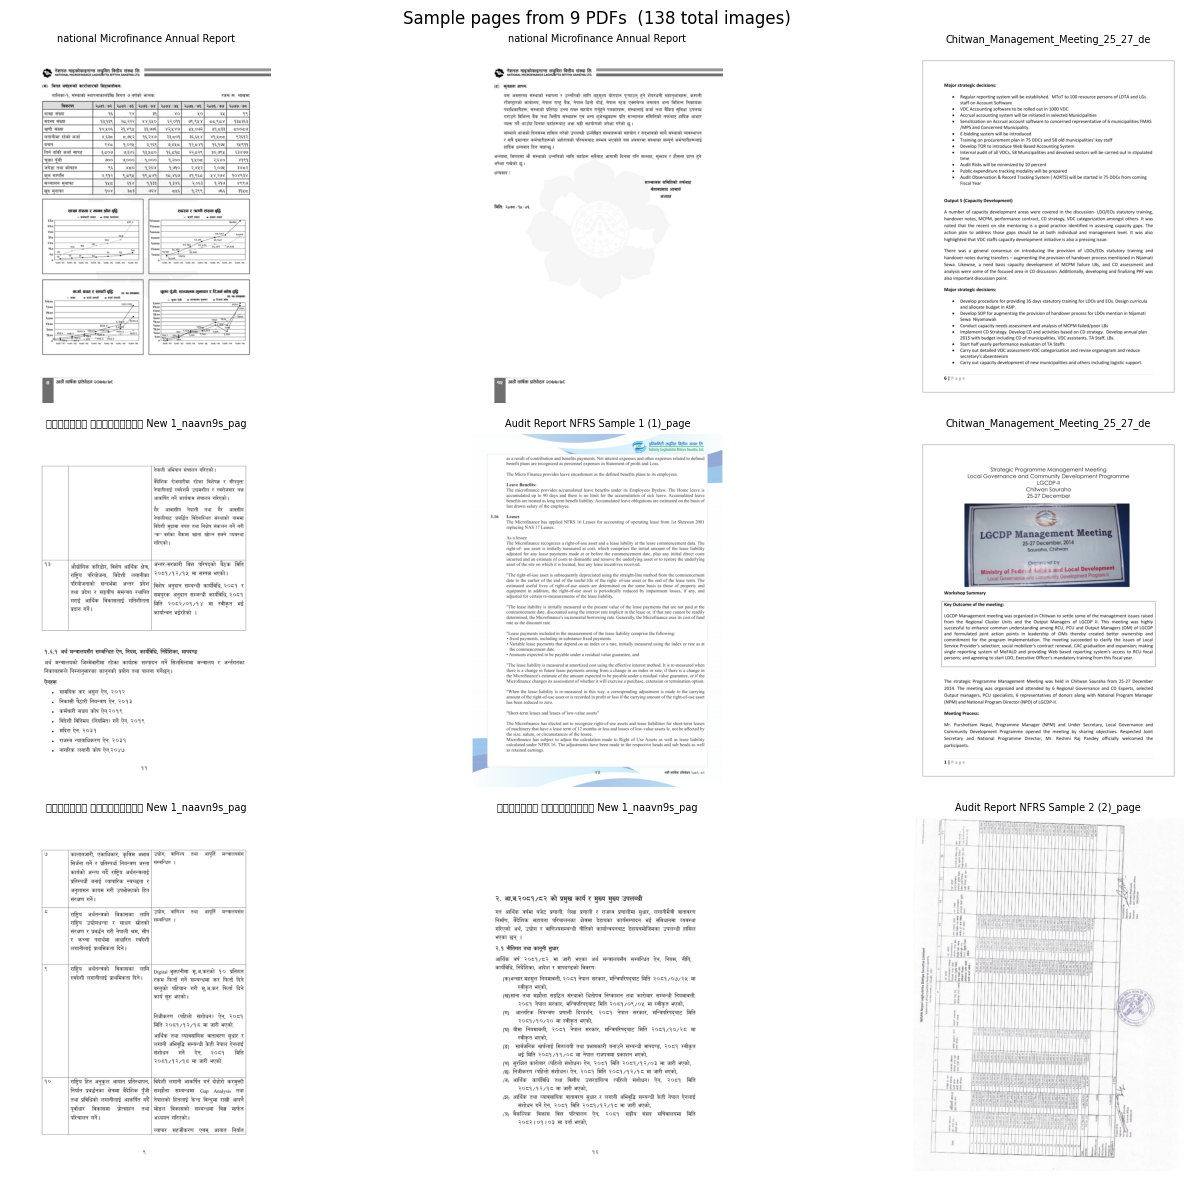

In [5]:
# ── Visual sanity check ───────────────────────────────────────────────────────
sample_paths = random.sample(list(RAW_DIR.glob('*.png')), min(9, len(manifest)))

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, path in zip(axes.flat, sample_paths):
    img = cv2.cvtColor(cv2.imread(str(path)), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(path.name[:35], fontsize=7)
    ax.axis('off')
# hide unused axes
for ax in axes.flat[len(sample_paths):]:
    ax.axis('off')
plt.suptitle(f'Sample pages from {len(pdfs)} PDFs  ({len(manifest)} total images)', fontsize=12)
plt.tight_layout()
plt.savefig(Path('../results/raw_sample.png'), dpi=120)
plt.show()